In [1]:
import os

# Change the current working directory to the path within Google Drive
os.chdir('/content/drive/MyDrive/Level_6_AI_')

# Verify the new current working directory
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/Level_6_AI_


In [2]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("./assets/image.png")

# img.show()  <- usually it's this, but this tries to open the local OS image viewer you have in your system. Won't work on remote.

# So, this for collab
display(img)

# Or, using matplot
plt.imshow(img)
plt.axis("off")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

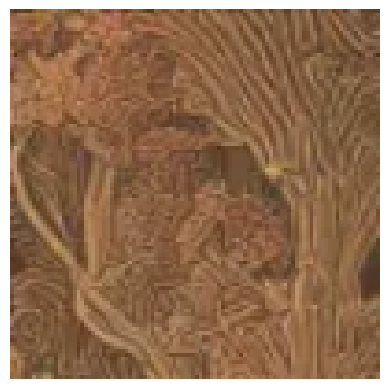

In [3]:
import numpy as np

# Convert To numpy array
img_arr = np.array(img)

# The same will be something like (height,width,channels)
top_left = img_arr[0:100, 0:100]

# display(top_left) won't work cause no top_left is an array, but
# plt.imshow() works

plt.imshow(top_left)
plt.axis("off")
plt.show()

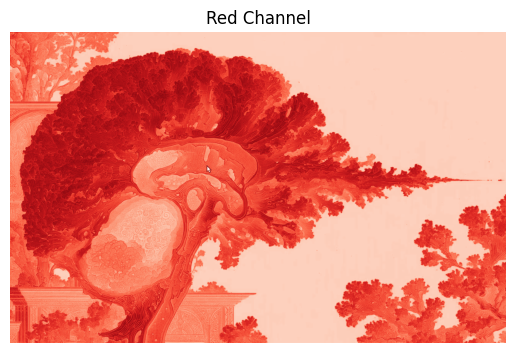

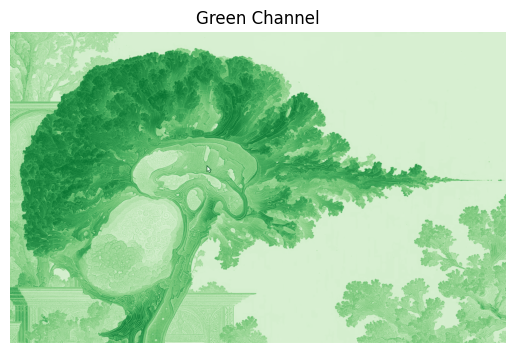

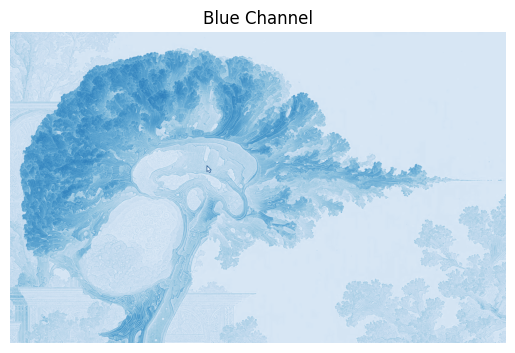

In [4]:
'''
Note that each of these channels is simply an intensity map.

If one were to just plt.imshow(img_arr[:,:,some_channel]), it would output a greyscale image, because the channel doesn't hold the color, just the intensity of said color.
'''


# Red channel
plt.imshow(img_arr[:, :, 0], cmap="Reds")
plt.title("Red Channel")
plt.axis("off")
plt.show()

# Green channel
plt.imshow(img_arr[:, :, 1], cmap="Greens")
plt.title("Green Channel")
plt.axis("off")
plt.show()

# Blue channel
plt.imshow(img_arr[:, :, 2], cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")
plt.show()


In [5]:
display(img)

img_arr[0:100,0:100] = 210
plt.imshow(img_arr)
plt.axis("off")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

(np.float64(-0.5), np.float64(1911.5), np.float64(1199.5), np.float64(-0.5))

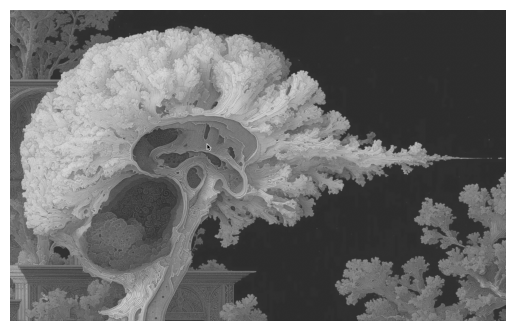

In [6]:
# Exercise 2

# greyscale_img = Image.open("./assets/greyscale_image.jpg")
# Converting the above picture to greyscale from online gave me 3 channels.

greyscale_img = img.convert("L")
plt.imshow(greyscale_img, cmap="gray")
plt.axis("off")


(np.float64(-0.5), np.float64(149.5), np.float64(149.5), np.float64(-0.5))

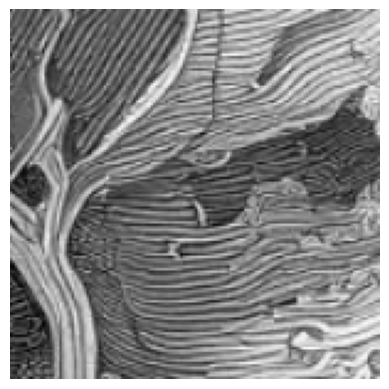

In [7]:
greyscale_img_arr = np.array(greyscale_img)
height,width= greyscale_img_arr.shape;
center_height,center_width = height//2, width//2

plt.imshow(
  greyscale_img_arr
  [
    center_height-75:center_height+75,
    center_width-75: center_width+75
  ],
  cmap="gray"
)

plt.axis("off")


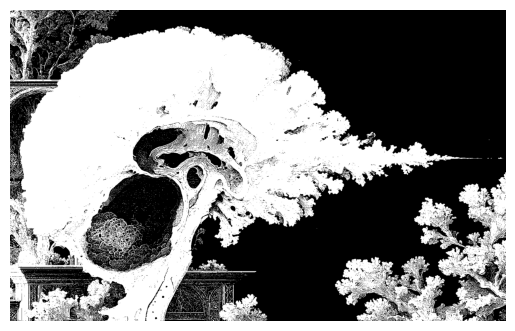

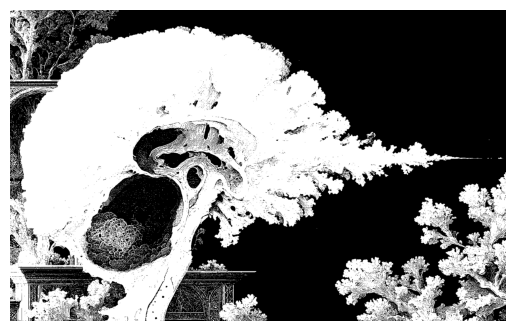

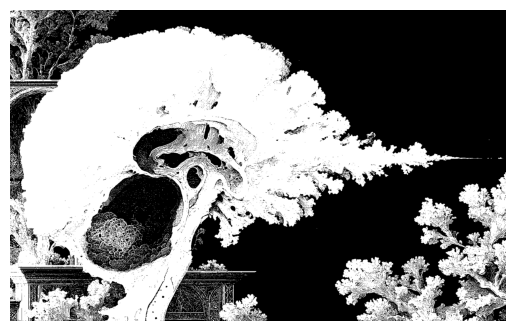

In [8]:
greyscale_img_arr[greyscale_img_arr < 100] = 0
greyscale_img_arr[greyscale_img_arr > 100] = 255
plt.imshow(greyscale_img_arr, cmap="gray")
plt.axis("off")
plt.show()

# or,
# Signature: np.where(condition, value_if_true, value_if_false)
binary_img = np.where(greyscale_img_arr < 100, 0, 255);
plt.imshow(binary_img, cmap="gray")
plt.axis("off")
plt.show()

# or even,
binary_img = (greyscale_img_arr >= 100) * 255
plt.imshow(binary_img, cmap="gray")
plt.axis("off")
plt.show()



In [9]:
# Rotate 90
display(greyscale_img)
display(greyscale_img.rotate(-90))


# To flip for a matrix
# 1 2 3
# 4 5 6
# 7 8 9
#
# Transpose:
# 1 4 7
# 2 5 8
# 3 6 9
#
# Flip Horizontally
# 7 4 1
# 8 5 2
# 9 6 3

greyscale_img_arr = np.array(greyscale_img)
transposed = np.transpose(greyscale_img_arr)
plt.imshow(transposed, cmap="gray")
plt.axis("off")

flipped = np.flip(transposed, axis=1)
plt.imshow(flipped, cmap="gray")
plt.axis("off")

Output hidden; open in https://colab.research.google.com to view.

In [10]:
greyscale_rgb = np.dstack((greyscale_img_arr, greyscale_img_arr, greyscale_img_arr))
plt.imshow(greyscale_rgb)
plt.axis("off")
plt.show()

# or,

greyscale_rgb = np.stack((greyscale_img_arr, greyscale_img_arr, greyscale_img_arr), axis=2)
plt.imshow(greyscale_rgb)
plt.axis("off")
plt.show()

# or,

greyscale_rgb = greyscale_img.convert("RGB")
display(greyscale_rgb)

Output hidden; open in https://colab.research.google.com to view.

(np.float64(-0.5), np.float64(1911.5), np.float64(1199.5), np.float64(-0.5))

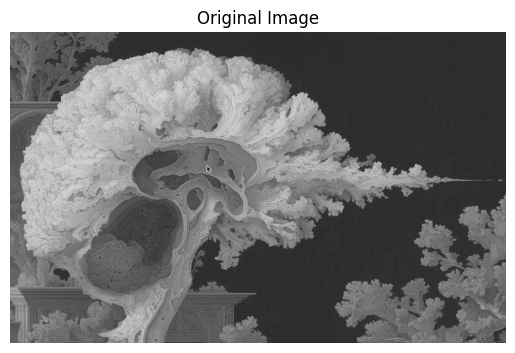

In [11]:
# --- Exercise 3


from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# load image
img = Image.open("./assets/image.png").convert("L")

# convert to numpy
img_arr = np.array(img, dtype=np.float64)

plt.imshow(img_arr, cmap="gray")
plt.title("Original Image")
plt.axis("off")

In [12]:
# Cener the data
mean = np.mean(img_arr, axis=0)
centered = img_arr - mean

In [13]:
# Covariance Matrix
cov_matrix = np.cov(centered, rowvar=False)

In [14]:
# Eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

In [15]:
# Sort Eigen Values
sorted_idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

In [16]:
# Choose top k principle components

k = 50
principal_components = eigenvectors[:, :k]

In [17]:
# Project The Image
compressed = np.dot(centered, principal_components)

(np.float64(-0.5), np.float64(1911.5), np.float64(1199.5), np.float64(-0.5))

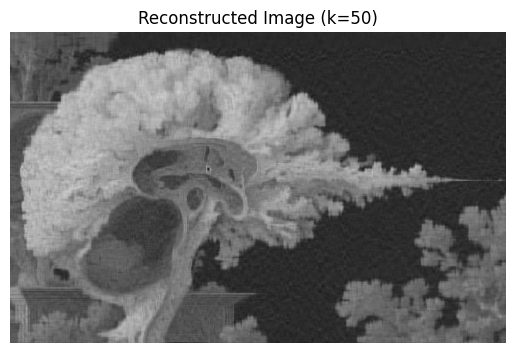

In [18]:
# Reconstruct
reconstructed = np.dot(compressed, principal_components.T) + mean

plt.imshow(reconstructed, cmap="gray")
plt.title(f"Reconstructed Image (k={k})")
plt.axis("off")

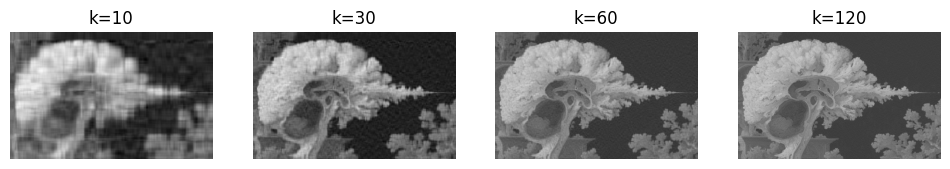

In [19]:
# Compare multiple PC Values
ks = [10, 30, 60, 120]

plt.figure(figsize=(12,6))

for i, k in enumerate(ks):

    pcs = eigenvectors[:, :k]

    compressed = np.dot(centered, pcs)

    reconstructed = np.dot(compressed, pcs.T) + mean

    plt.subplot(1,4,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"k={k}")
    plt.axis("off")

plt.show()

Loaded: ./assets/image.png
Original (Pillow) size (W,H): (1912, 1200)
Grayscale array shape (H,W): (1200, 1912) dtype: float64


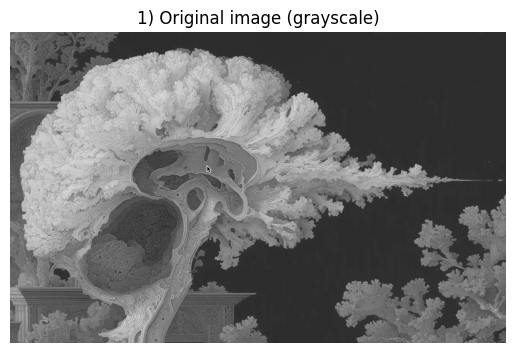

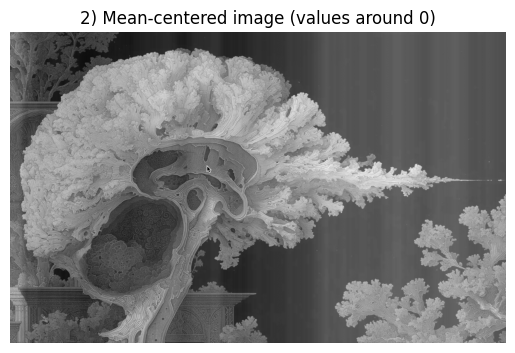

Covariance matrix shape: (1912, 1912)


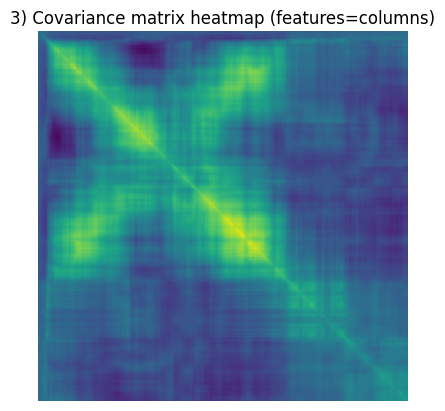

Top 10 explained variance ratios: [0.37501224 0.20627808 0.09874749 0.04336979 0.0274261  0.021338
 0.01730811 0.01465098 0.01352382 0.00970929]
Cumulative explained variance at k=10: 0.8273639157747958


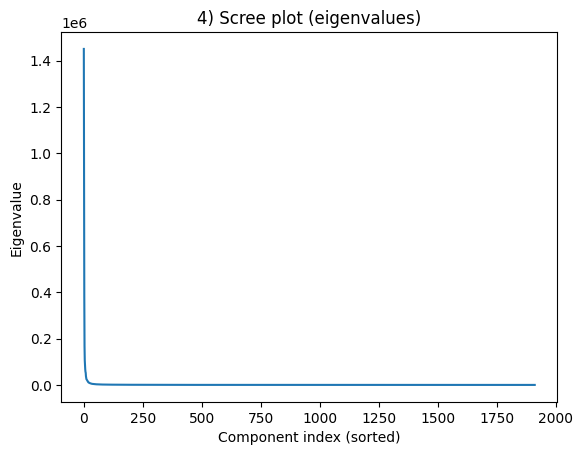

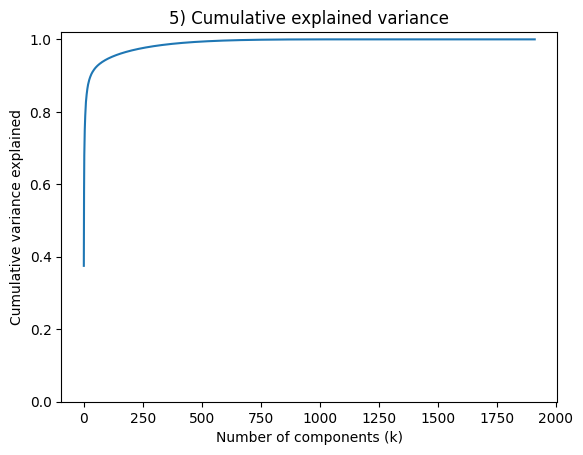

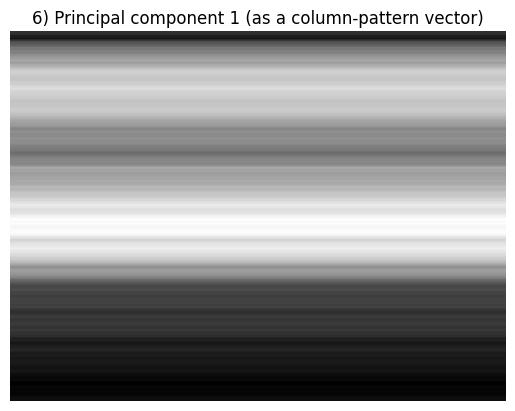

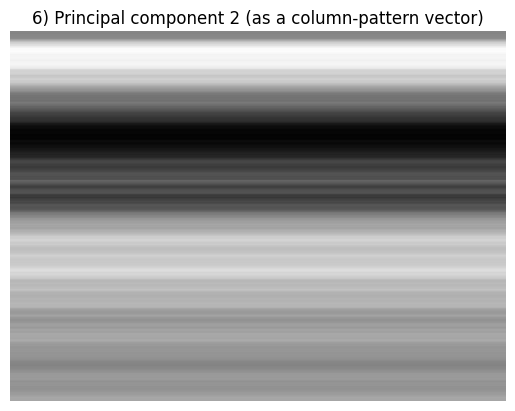

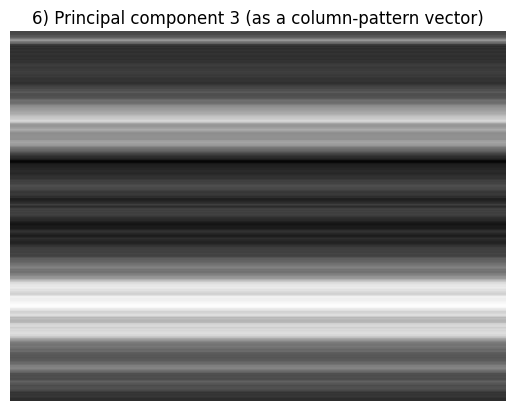

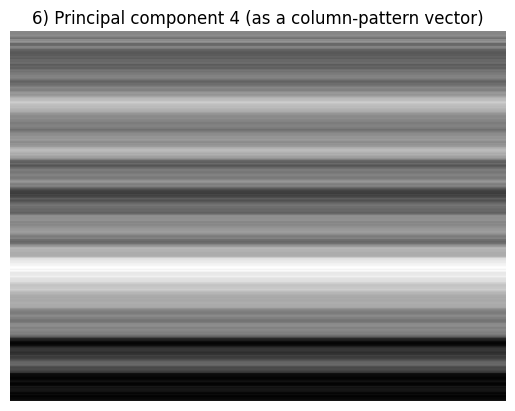

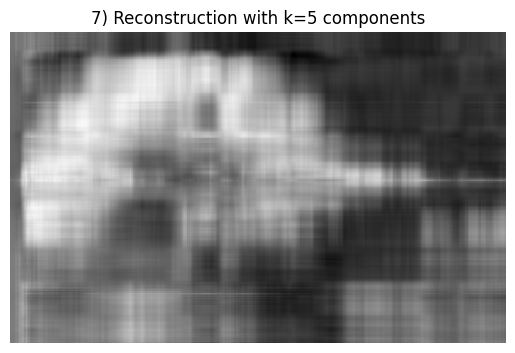

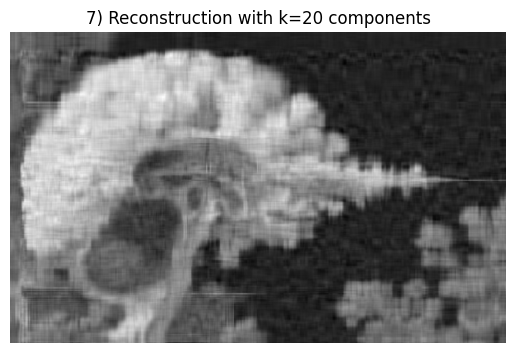

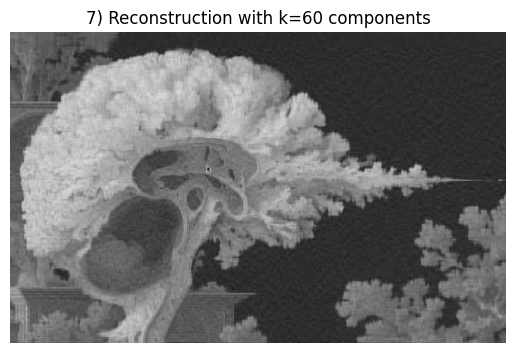

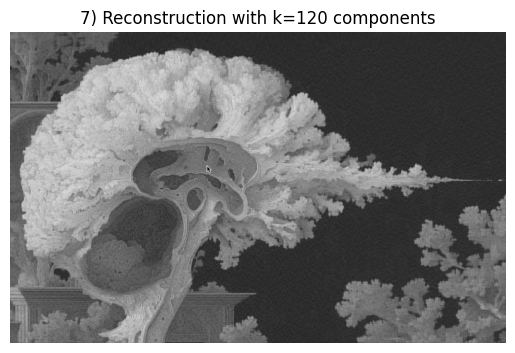

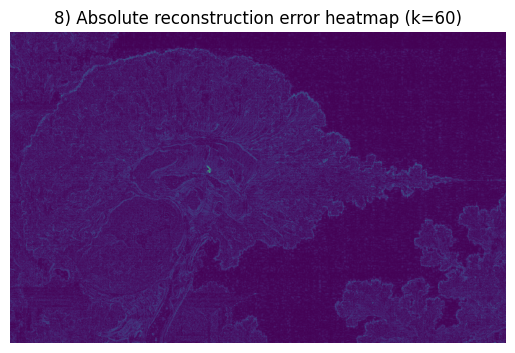

In [20]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ---- Load an example image (using the one in this chat) ----
img_path = "./assets/image.png"
img = Image.open(img_path)

# Convert to grayscale (2D)
gray_img = img.convert("L")
X = np.array(gray_img, dtype=np.float64)  # shape: (H, W)

print("Loaded:", img_path)
print("Original (Pillow) size (W,H):", img.size)
print("Grayscale array shape (H,W):", X.shape, "dtype:", X.dtype)

# ---- 1) Show the original grayscale image ----
plt.figure()
plt.imshow(X, cmap="gray")
plt.title("1) Original image (grayscale)")
plt.axis("off")
plt.show()

# ---- 2) Mean-center the data (column-wise) ----
# Treat each row as a sample and each column as a feature (common for PCA on images)
mu = X.mean(axis=0, keepdims=True)          # shape (1, W)
Xc = X - mu                                 # centered data

plt.figure()
plt.imshow(Xc, cmap="gray")
plt.title("2) Mean-centered image (values around 0)")
plt.axis("off")
plt.show()

# ---- 3) Covariance matrix (W x W) ----
# Cov of features (columns): cov = (Xc^T Xc) / (n-1)
n = Xc.shape[0]
cov = (Xc.T @ Xc) / (n - 1)

print("Covariance matrix shape:", cov.shape)

# Visualize covariance heatmap
plt.figure()
plt.imshow(cov)  # default colormap
plt.title("3) Covariance matrix heatmap (features=columns)")
plt.axis("off")
plt.show()

# ---- 4) Eigen decomposition ----
# cov is symmetric -> use eigh
eigvals, eigvecs = np.linalg.eigh(cov)

# Sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Explained variance ratio
explained = eigvals / eigvals.sum()
cum_explained = np.cumsum(explained)

print("Top 10 explained variance ratios:", explained[:10])
print("Cumulative explained variance at k=10:", cum_explained[9])

# ---- 5) Scree plot (eigenvalues) ----
plt.figure()
plt.plot(eigvals)
plt.title("4) Scree plot (eigenvalues)")
plt.xlabel("Component index (sorted)")
plt.ylabel("Eigenvalue")
plt.show()

# ---- 6) Cumulative explained variance ----
plt.figure()
plt.plot(cum_explained)
plt.title("5) Cumulative explained variance")
plt.xlabel("Number of components (k)")
plt.ylabel("Cumulative variance explained")
plt.ylim(0, 1.02)
plt.show()

# ---- 7) Visualize a few principal components as images ----
# Each eigenvector is length W (one value per column). To visualize, we can reshape as (W,1)
# (This is a limitation of doing covariance over columns only; still useful to "see" patterns.)
for i in [0, 1, 2, 3]:
    pc = eigvecs[:, i]  # length W
    plt.figure()
    plt.imshow(pc.reshape(-1, 1), cmap="gray", aspect="auto")
    plt.title(f"6) Principal component {i+1} (as a column-pattern vector)")
    plt.axis("off")
    plt.show()

# ---- 8) Compress + reconstruct for several k ----
# Projection: Z = Xc @ V_k  (H x k)
# Reconstruction: X_hat = Z @ V_k^T + mu
ks = [5, 20, 60, 120]
for k in ks:
    Vk = eigvecs[:, :k]
    Z = Xc @ Vk
    Xhat = (Z @ Vk.T) + mu
    Xhat = np.clip(Xhat, 0, 255)

    plt.figure()
    plt.imshow(Xhat, cmap="gray")
    plt.title(f"7) Reconstruction with k={k} components")
    plt.axis("off")
    plt.show()

# ---- 9) Show "difference image" for one k (error visualization) ----
k = 60
Vk = eigvecs[:, :k]
Z = Xc @ Vk
Xhat = (Z @ Vk.T) + mu
err = np.abs(X - Xhat)

plt.figure()
plt.imshow(err)  # default colormap to highlight magnitude differences
plt.title(f"8) Absolute reconstruction error heatmap (k={k})")
plt.axis("off")
plt.show()